<h1 style="color:#1D4E89;">ĐỒ ÁN 2: DATA FITTING VÀ PHƯƠNG PHÁP OLS</h1>
<h3 style="color:#555; font-weight:400; margin-top:-8px;">Phần 1: Lý Thuyết và Minh Họa</h3>

---

| Thông tin | Chi tiết |
|---|---|
| **Môn học** | Toán Ứng Dụng và Thống Kê (MTH00051) |
| **Nhóm** | Nhóm 02 |
| **Giảng viên** | Khoa Công nghệ Thông tin – ĐHKHTN TP.HCM |
| **Học kỳ** | HK2, năm học 2025–2026 |

---

### Cách trình bày

Ở phần này, nhóm trình bày các nội dung theo cùng một mạch để dễ theo dõi:

- **(a)** Nhắc lại công thức chính
- **(b)** Gọi hàm Python do nhóm tự cài đặt trong `part1/`
- **(c)** Minh họa bằng dữ liệu mô phỏng
- **(d)** Kiểm chứng lại bằng NumPy hoặc scikit-learn khi cần

---
## 0. Thiết lập môi trường

In [20]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as sp_stats

sys.path.insert(0, os.getcwd())
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

C = {
    'primary'  : '#2166AC',
    'secondary': '#D6604D',
    'good'     : '#1A9850',
    'warn'     : '#E08214',
    'bad'      : '#C0392B',
    'neutral'  : '#636363',
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': '#F7F9FC', 'axes.facecolor': '#F7F9FC',
    'axes.unicode_minus': False, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.alpha': 0.4, 'lines.linewidth': 2,
})
SEED = 42
np.random.seed(SEED)
print('Môi trường đã sẵn sàng.')

Môi trường đã sẵn sàng.


**Dữ liệu mô phỏng dùng trong phần minh họa:**

Nhóm dùng dữ liệu mô phỏng vì ở phần này mục tiêu chính là kiểm tra công thức và cách cài đặt. Khi biết trước hệ số thật, ta có thể so sánh trực tiếp với kết quả ước lượng.

$$y = X\beta_{\text{true}} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2 I)$$

với $\beta_{\text{true}} = [2.5, 1.5, -3.0, 0.8]^T$, $\sigma=0.5$, $n=150$, $p=3$.

In [21]:
np.random.seed(SEED)
n_samples, p_features = 150, 3
X_raw  = np.random.randn(n_samples, p_features)
X_sim  = np.column_stack([np.ones(n_samples), X_raw])
beta_true  = np.array([2.5, 1.5, -3.0, 0.8])
sigma_true = 0.5
y_sim = X_sim @ beta_true + np.random.normal(0, sigma_true, n_samples)
print(f'X: {X_sim.shape} | y: {y_sim.shape}')
print(f'beta_true = {beta_true}')

X: (150, 4) | y: (150,)
beta_true = [ 2.5  1.5 -3.   0.8]


---
## <span style="color:#1D4E89;">1. Hồi quy OLS</span> — `ols_fit(X, y)`

### (a) Công thức sử dụng

**Mô hình:** $y = X\beta + \epsilon$, $\quad\epsilon \sim \mathcal{N}(0, \sigma^2 I)$

Ý tưởng của OLS là chọn vector $\beta$ sao cho các giá trị dự báo $X\beta$ gần với $y$ nhất theo tổng bình phương sai số. Nhóm dùng bình phương sai số vì hàm này dễ đạo hàm và phạt mạnh hơn các sai lệch lớn.

Trong đó, $X$ là ma trận dữ liệu đã thêm cột hệ số tự do, $y$ là vector giá trị quan sát, $\beta$ là vector hệ số cần ước lượng và $\epsilon$ là phần nhiễu chưa giải thích được. Khi giả thiết $X^TX$ khả nghịch, nghiệm OLS có thể viết trực tiếp bằng công thức ma trận.

**Hàm mất mát — RSS:**
$$\text{RSS}(\beta) = \|y - X\beta\|_2^2$$

Tính gradient của RSS và đặt bằng $0$:
$$\nabla_\beta\,\text{RSS} = -2X^T(y - X\beta) = 0 \;\Longrightarrow\; X^TX\beta = X^Ty \quad \text{(hệ phương trình chuẩn)}$$

$$\boxed{\hat{\beta}_{\text{OLS}} = (X^TX)^{-1}X^Ty}$$

Công thức này xuất phát từ điều kiện cực tiểu của RSS. Trong code, nhóm giải hệ phương trình chuẩn thay vì nhân nghịch đảo trực tiếp để tránh một số sai số số học khi ma trận gần suy biến.

**Ước lượng phương sai nhiễu không chệch:**
$$\hat{\sigma}^2 = \frac{\text{RSS}}{n - p - 1}$$

> Mẫu số $n-p-1$ là bậc tự do còn lại sau khi ước lượng $p+1$ tham số.

In [22]:
from ols_implementation import ols_fit
from sklearn.linear_model import LinearRegression

beta_hat, sigma2_hat = ols_fit(X_sim, y_sim)
sk_lr = LinearRegression(fit_intercept=False).fit(X_sim, y_sim)

print('KẾT QUẢ ƯỚC LƯỢNG OLS')
print(f'Beta thực tế  : {beta_true.tolist()}')
print(f'Beta ước lượng: {[round(float(v), 4) for v in beta_hat]}')
print(f'Sigma^2 thực tế  : {sigma_true**2:.6f}')
print(f'Sigma^2 ước lượng: {sigma2_hat:.6f}')
print(f'(d) Beta sklearn  : {[round(float(v),4) for v in sk_lr.coef_]}')
print(f'    Trùng khớp    : {np.allclose(beta_hat, sk_lr.coef_, atol=1e-8)}')

KẾT QUẢ ƯỚC LƯỢNG OLS
Beta thực tế  : [2.5, 1.5, -3.0, 0.8]
Beta ước lượng: [2.4539, 1.4791, -2.9868, 0.8022]
Sigma^2 thực tế  : 0.250000
Sigma^2 ước lượng: 0.239899
(d) Beta sklearn  : [2.4539, 1.4791, -2.9868, 0.8022]
    Trùng khớp    : True


### (c) Trực quan hóa — So sánh Beta thực tế và ước lượng

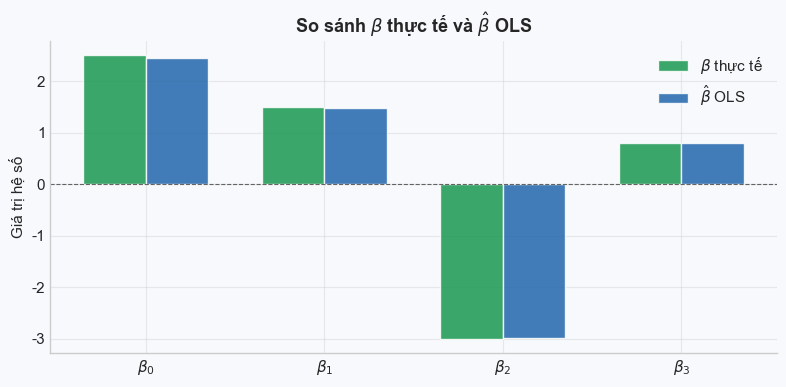

In [23]:
x_pos, w = np.arange(len(beta_hat)), 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos-w/2, beta_true, w, label='$\\beta$ thực tế', color=C['good'], alpha=0.85, edgecolor='white')
ax.bar(x_pos+w/2, beta_hat,  w, label='$\\hat{\\beta}$ OLS', color=C['primary'], alpha=0.85, edgecolor='white')
ax.axhline(0, color=C['neutral'], linewidth=0.8, linestyle='--')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'$\\beta_{j}$' for j in range(len(beta_hat))])
ax.set_ylabel('Giá trị hệ số'); ax.set_title('So sánh $\\beta$ thực tế và $\\hat{\\beta}$ OLS')
ax.legend(); plt.tight_layout(); plt.show()

> **Nhận xét:** $\hat{\beta}_{\text{OLS}}$ khá gần với $\beta_{\text{true}}$. Sai lệch nhỏ xuất hiện do dữ liệu có nhiễu $\epsilon$. Kết quả kiểm chứng bằng scikit-learn cho cùng hệ số trong sai số rất nhỏ.

---
## <span style="color:#1D4E89;">2. Ma trận chiếu H</span> — `hat_matrix(X)`

### (a) Lý thuyết

$$H = X(X^TX)^{-1}X^T \in \mathbb{R}^{n \times n}$$

Giá trị dự báo: $\hat{y} = Hy$; phần dư: $\hat{\epsilon} = (I-H)y$.

Ma trận $H$ cho thấy dự báo OLS thực chất là phép chiếu vector $y$ lên không gian sinh bởi các cột của $X$. Vì vậy, các tính chất như đối xứng và lũy đẳng không chỉ là kiểm tra đại số, mà còn giúp hiểu vì sao $\hat{y}$ là phần gần $y$ nhất trong không gian mô hình.

Đường chéo của $H$, ký hiệu $h_{ii}$, thường được gọi là leverage. Giá trị này cho biết quan sát thứ $i$ có ảnh hưởng hình học lớn hay nhỏ đến giá trị dự báo của chính nó; vì vậy nhóm dùng thêm biểu đồ leverage ở phần minh họa.

**Mệnh đề 1.1 — Năm tính chất của $H$:**

| # | Tính chất | Phát biểu |
|---|---|---|
| (i) | Lũy đẳng | $H^2 = H$ |
| (ii) | Đối xứng | $H^T = H$ |
| (iii) | Giá trị riêng | Giá trị riêng của $H$ chỉ là $0$ hoặc $1$ |
| (iv) | Hạng | $\text{tr}(H) = p + 1$ |
| (v) | Chiếu | $\hat{y} = Hy$; $\hat{\epsilon} = (I-H)y$ |

In [24]:
from ols_implementation import hat_matrix

H  = hat_matrix(X_sim)
n, p1 = X_sim.shape[0], X_sim.shape[1]
evals  = np.linalg.eigvalsh(H)

checks = {
    '(i)   H^2 = H'             : np.allclose(H @ H, H, atol=1e-8),
    '(ii)  H^T = H'             : np.allclose(H, H.T, atol=1e-8),
    '(iii) Eigenvalue in {0,1}' : np.all((evals < 1e-7) | (np.abs(evals-1) < 1e-7)),
    f'(iv)  tr(H) = {p1}'       : np.isclose(np.trace(H), p1, atol=1e-6),
    '(v)   y_hat = H @ y'       : np.allclose(H @ y_sim, X_sim @ beta_hat, atol=1e-8),
}
print('KIỂM CHỨNG 5 TÍNH CHẤT CỦA H')
for label, ok in checks.items():
    print(f'  {label:<30}: {"OK" if ok else "FAIL"}')

KIỂM CHỨNG 5 TÍNH CHẤT CỦA H
  (i)   H^2 = H                 : OK
  (ii)  H^T = H                 : OK
  (iii) Eigenvalue in {0,1}     : OK
  (iv)  tr(H) = 4               : OK
  (v)   y_hat = H @ y           : OK


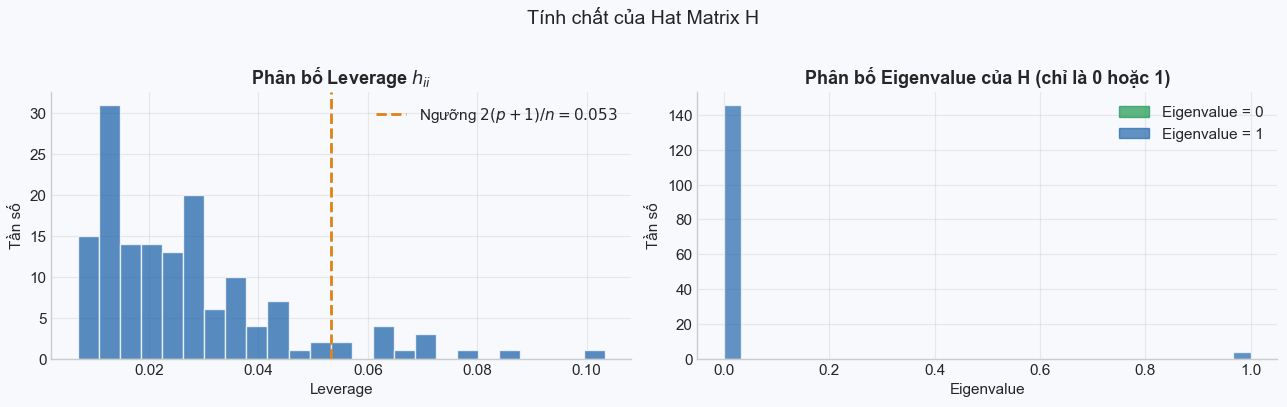

Leverage cao (> 0.053): 13/150 quan sát


In [25]:
leverage = np.diag(H)
threshold_lev = 2 * p1 / n
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(leverage, bins=25, color=C['primary'], alpha=0.75, edgecolor='white')
axes[0].axvline(threshold_lev, color=C['warn'], linestyle='--', linewidth=2,
                label=f'Ngưỡng $2(p+1)/n = {threshold_lev:.3f}$')
axes[0].set_title('Phân bố độ ảnh hưởng $h_{ii}$'); axes[0].set_xlabel('Leverage')
axes[0].set_ylabel('Tần số'); axes[0].legend()
p0  = mpatches.Patch(color=C['good'],    alpha=0.7, label='Giá trị riêng = 0')
p1l = mpatches.Patch(color=C['primary'], alpha=0.7, label='Giá trị riêng = 1')
axes[1].hist(evals, bins=30, color=C['primary'], alpha=0.7, edgecolor='white')
axes[1].set_title('Phân bố giá trị riêng của H')
axes[1].set_xlabel('Giá trị riêng'); axes[1].set_ylabel('Tần số')
axes[1].legend(handles=[p0, p1l])
fig.suptitle('Tính chất của Hat Matrix H', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()
print(f'Leverage cao (> {threshold_lev:.3f}): {np.sum(leverage > threshold_lev)}/{n} quan sát')

> **Nhận xét:** Các kiểm tra đều cho kết quả đúng với lý thuyết. Điều này giúp xác nhận cách tính ma trận $H$ trong hàm `hat_matrix`.

---
## <span style="color:#1D4E89;">3. Chỉ số đánh giá mô hình</span> — `model_metrics(y, y_hat, p)`

### (a) Lý thuyết

Sau khi ước lượng được $\hat{\beta}$, nhóm không chỉ nhìn vào hệ số mà còn kiểm tra mô hình fit dữ liệu tốt đến mức nào. Các chỉ số dưới đây được dùng cho phần đánh giá đó.

RSS đo phần sai số còn lại sau khi fit mô hình, còn TSS đo tổng độ biến thiên ban đầu của $y$ quanh trung bình. Vì vậy $R^2 = 1 - RSS/TSS$ có thể hiểu là tỉ lệ biến thiên của $y$ được mô hình giải thích. $R^2$ hiệu chỉnh được dùng thêm vì $R^2$ thường tăng khi thêm biến, kể cả khi biến mới không thật sự hữu ích.

| Chỉ số | Công thức | Ý nghĩa |
|---|---|---|
| RSS | $\sum(y_i - \hat{y}_i)^2$ | Tổng bình phương phần dư |
| TSS | $\sum(y_i - \bar{y})^2$ | Tổng bình phương tổng thể |
| $R^2$ | $1 - \text{RSS}/\text{TSS}$ | Tỉ lệ phương sai được giải thích |
| $\bar{R}^2$ | $1 - \frac{n-1}{n-p-1}(1-R^2)$ | $R^2$ hiệu chỉnh |
| F | $\frac{(\text{TSS}-\text{RSS})/p}{\text{RSS}/(n-p-1)}$ | Kiểm định ý nghĩa tổng thể |

**Kiểm định F** — $H_0: \beta_1 = \cdots = \beta_p = 0$:
$$F = \frac{(\text{TSS}-\text{RSS})/p}{\text{RSS}/(n-p-1)} \sim F_{p,\,n-p-1}$$

Kiểm định F xem xét mô hình một cách tổng thể: nếu bác bỏ $H_0$, ta có bằng chứng rằng ít nhất một biến giải thích có liên hệ tuyến tính với biến mục tiêu. Đây là bước khác với kiểm định $t$, vốn kiểm tra từng hệ số riêng lẻ.

> Bác bỏ $H_0$ khi p-value $< 0.05$: mô hình có ít nhất một biến có ý nghĩa thống kê.

In [26]:
from ols_implementation import model_metrics
from sklearn.metrics import r2_score
from scipy.stats import f as f_dist

y_hat = X_sim @ beta_hat
RSS, TSS, r2, adj_r2, f_stat = model_metrics(y_sim, y_hat, p_features)
f_pval = 1 - f_dist.cdf(f_stat, dfn=p_features, dfd=n_samples-p_features-1)
r2_sk  = r2_score(y_sim, y_hat)

print('ĐÁNH GIÁ MÔ HÌNH HỒI QUY')
print(f'  R^2              : {r2:.6f}')
print(f'  R^2 hiệu chỉnh   : {adj_r2:.6f}')
print(f'  Thống kê F       : {f_stat:.4f}')
print(f'  F p-value        : {f_pval:.2e}')
print(f'  RSS / TSS        : {RSS:.4f} / {TSS:.4f}')
print(f'(d) R^2 sklearn    : {r2_sk:.6f} | Trùng khớp: {np.isclose(r2, r2_sk)}')
print(f'Nhận xét: R^2={r2:.4f} → mô hình giải thích {r2*100:.1f}% phương sai.')
print(f'F={f_stat:.2f}, p={f_pval:.2e} << 0.05 → bác bỏ H0.')

ĐÁNH GIÁ MÔ HÌNH HỒI QUY
  R^2              : 0.978806
  Adjusted R^2     : 0.978371
  F-statistic      : 2247.6135
  F p-value        : 0.00e+00
  RSS / TSS        : 35.0252 / 1652.6229
(d) R^2 sklearn    : 0.978806 | Trùng khớp: True
Nhận xét: R^2=0.9788 → mô hình giải thích 97.9% phương sai.
F=2247.61, p=0.00e+00 << 0.05 → bác bỏ H0.


> **Nhận xét:** Vì dữ liệu được tạo từ mô hình tuyến tính nên $R^2$ khá cao. Kiểm định F có p-value rất nhỏ, nên có cơ sở bác bỏ giả thuyết các hệ số góc đều bằng $0$.

---
## <span style="color:#1D4E89;">4. Suy diễn thống kê hệ số hồi quy</span> — `coef_inference(...)`

### (a) Lý thuyết

Dưới giả thiết GM5: $\hat{\beta} \sim \mathcal{N}(\beta,\ \sigma^2(X^TX)^{-1})$.

Sau khi có hệ số ước lượng, nhóm cần biết hệ số đó có đáng tin cậy hay không. Vì vậy ta tính sai số chuẩn, thống kê $t$, p-value và khoảng tin cậy để xem từng biến có đóng góp rõ ràng trong mô hình hay chỉ dao động do nhiễu.

$$\text{SE}(\hat{\beta}_j) = \sqrt{\hat{\sigma}^2 [(X^TX)^{-1}]_{jj}}, \qquad t_j = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)} \sim t_{n-p-1}$$

Sai số chuẩn càng nhỏ thì hệ số ước lượng càng ổn định quanh giá trị thật. Thống kê $t$ so sánh độ lớn của hệ số với mức dao động của nó; p-value nhỏ cho thấy hệ số đó khó có thể chỉ xuất hiện do nhiễu nếu giả thuyết $\beta_j=0$ là đúng.

**Khoảng tin cậy 95%:**
$$\hat{\beta}_j \pm t_{0.975,\,n-p-1} \cdot \text{SE}(\hat{\beta}_j)$$

In [27]:
from ols_implementation import coef_inference

se, t_stats, p_values, ci_lower, ci_upper = coef_inference(
    X_sim, y_sim, beta_hat, sigma2_hat)

names = ['Intercept', 'beta_1', 'beta_2', 'beta_3']
print('=' * 84)
print('BẢNG SUY DIỄN THỐNG KÊ HỆ SỐ HỒI QUY (95% CI)')
print('=' * 84)
print(f"{'Hệ số':<12}{'Thực tế':<10}{'Ước lượng':<12}{'SE':<10}{'t-stat':<10}{'p-value':<13}{'CI 95%'}")
print('-' * 84)
for j in range(len(beta_hat)):
    sig = '***' if p_values[j]<0.001 else ('**' if p_values[j]<0.01 else ('*' if p_values[j]<0.05 else ''))
    ci  = f'[{ci_lower[j]:.3f}, {ci_upper[j]:.3f}]'
    print(f"{names[j]:<12}{beta_true[j]:<10.4f}{beta_hat[j]:<12.4f}{se[j]:<10.4f}{t_stats[j]:<10.3f}{p_values[j]:<13.4e}{ci} {sig}")
print('  *** p<0.001  ** p<0.01  * p<0.05')

BẢNG SUY DIỄN THỐNG KÊ HỆ SỐ HỒI QUY (95% CI)
Hệ số       Thực tế   Ước lượng   SE        t-stat    p-value      CI 95%
------------------------------------------------------------------------------------
Intercept   2.5000    2.4539      0.0406    60.423    0.0000e+00   [2.374, 2.534] ***
beta_1      1.5000    1.4791      0.0457    32.354    0.0000e+00   [1.389, 1.569] ***
beta_2      -3.0000   -2.9868     0.0411    -72.687   0.0000e+00   [-3.068, -2.906] ***
beta_3      0.8000    0.8022      0.0387    20.714    0.0000e+00   [0.726, 0.879] ***
  *** p<0.001  ** p<0.01  * p<0.05


### (c) Trực quan hóa — Hệ số và Khoảng tin cậy 95%

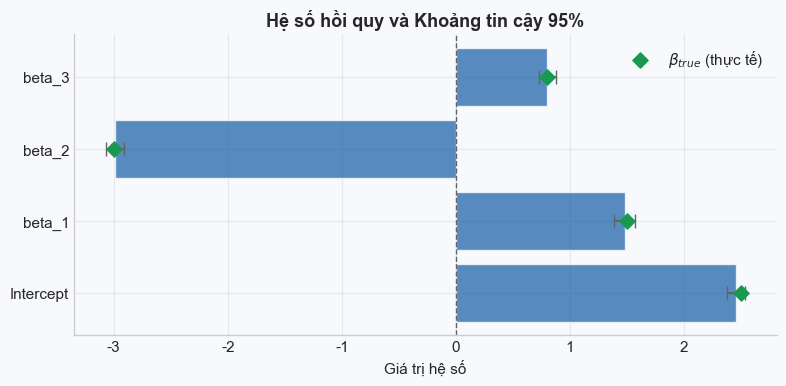

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
y_pos = np.arange(len(beta_hat))
ax.barh(y_pos, beta_hat, xerr=[beta_hat-ci_lower, ci_upper-beta_hat],
        color=C['primary'], alpha=0.75, edgecolor='white',
        error_kw=dict(ecolor=C['neutral'], capsize=5, linewidth=1.5))
ax.scatter(beta_true, y_pos, color=C['good'], zorder=5, s=60,
           label='$\\beta_{true}$ (thực tế)', marker='D')
ax.axvline(0, color=C['neutral'], linestyle='--', linewidth=1)
ax.set_yticks(y_pos); ax.set_yticklabels(names)
ax.set_xlabel('Giá trị hệ số')
ax.set_title('Hệ số hồi quy và Khoảng tin cậy 95%')
ax.legend(); plt.tight_layout(); plt.show()

> **Nhận xét:** Trên bộ dữ liệu mô phỏng này, các hệ số đều có p-value nhỏ. Khoảng tin cậy 95% cũng chứa giá trị hệ số thật mà nhóm dùng để sinh dữ liệu.

---
## <span style="color:#1D4E89;">5. Đa cộng tuyến và chỉ số VIF</span> — `vif(X)`

### (a) Lý thuyết

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

trong đó $R_j^2$ là $R^2$ khi hồi quy $X_j$ theo các biến còn lại.

Nếu một biến có thể được giải thích gần như hoàn toàn bởi các biến còn lại, $R_j^2$ sẽ lớn và VIF cũng tăng mạnh. Khi đó hệ số hồi quy có thể trở nên nhạy với dữ liệu, nên nhóm cần kiểm tra đa cộng tuyến trước khi diễn giải hệ số.

VIF không trực tiếp nói biến nào quan trọng hơn, mà chỉ cảnh báo mức trùng lặp thông tin giữa các biến đầu vào. Trong ví dụ minh họa, nhóm tạo thêm một bộ dữ liệu có hai biến gần tuyến tính với nhau để thấy VIF tăng mạnh như thế nào.

| Mức VIF | Chẩn đoán |
|---|---|
| $< 5$ | Chấp nhận được |
| $5 \leq \text{VIF} < 10$ | Đa cộng tuyến trung bình |
| $\geq 10$ | Nghiêm trọng, cần xem xét xử lý |

In [29]:
from ols_implementation import vif

vif_normal = vif(X_sim)
np.random.seed(SEED)
x_base  = np.random.randn(n_samples)
x_corr  = x_base + np.random.normal(0, 0.02, n_samples)
x_indep = np.random.randn(n_samples)
X_coll  = np.column_stack([np.ones(n_samples), x_base, x_corr, x_indep])
vif_coll = vif(X_coll)

var_names = ['X1', 'X2', 'X3']
print(f"{'Biến':<6} {'VIF (bình thường)':<22} {'VIF (đa cộng tuyến)'}")
print('-' * 52)
for j, nm in enumerate(var_names):
    flag = '  [NGHIÊM TRỌNG]' if vif_coll[j] > 10 else ''
    print(f"{nm:<6} {vif_normal[j]:<22.4f} {vif_coll[j]:.2f}{flag}")

Biến   VIF (bình thường)      VIF (đa cộng tuyến)
----------------------------------------------------
X1     1.0062                 2129.76  [NGHIÊM TRỌNG]
X2     1.0065                 2129.64  [NGHIÊM TRỌNG]
X3     1.0099                 1.00


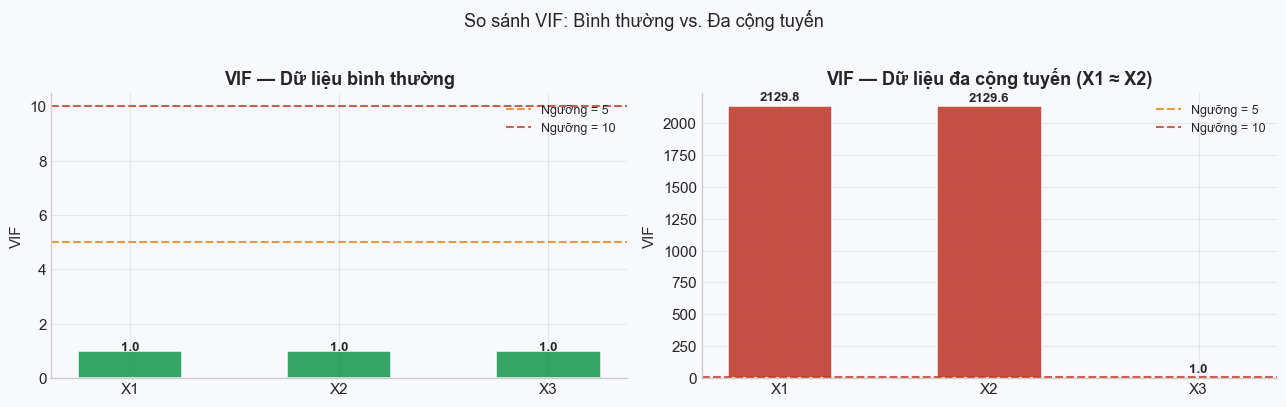

In [30]:
def vif_color(v): return C['good'] if v<5 else (C['warn'] if v<10 else C['bad'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, vals, title in [
    (axes[0], vif_normal, 'VIF — Dữ liệu bình thường'),
    (axes[1], vif_coll,   'VIF — Dữ liệu đa cộng tuyến (X1 ≈ X2)'),
]:
    cols = [vif_color(v) for v in vals]
    bars = ax.bar(var_names, vals, color=cols, edgecolor='white', linewidth=1.2, width=0.5, alpha=0.88)
    ax.axhline(5,  color=C['warn'], linestyle='--', linewidth=1.5, label='Ngưỡng = 5',  alpha=0.8)
    ax.axhline(10, color=C['bad'],  linestyle='--', linewidth=1.5, label='Ngưỡng = 10', alpha=0.8)
    ax.set_title(title); ax.set_ylabel('VIF'); ax.legend(fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.02,
                f'{val:.1f}', ha='center', fontsize=9.5, fontweight='bold')
fig.suptitle('So sánh VIF: Bình thường vs. Đa cộng tuyến', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

---
## <span style="color:#1D4E89;">6. Chính quy hóa Ridge và Lasso</span> — `ridge_fit(X, y, lam)`

### (a) Lý thuyết

OLS hoạt động tốt trong ví dụ cơ bản, nhưng khi dữ liệu có nhiều biến hoặc có đa cộng tuyến thì nghiệm có thể kém ổn định hơn. Vì vậy nhóm thêm Ridge và Lasso để quan sát tác dụng của chính quy hóa.

Ridge làm hệ số nhỏ lại theo chuẩn $L_2$, thường giúp mô hình bớt nhạy khi các biến tương quan với nhau. Lasso dùng chuẩn $L_1$, nên ngoài việc co hệ số còn có thể đưa một số hệ số về đúng $0$; điểm này hữu ích khi muốn nhận ra biến nào ít đóng góp trong ví dụ mô phỏng.

**Hồi quy Ridge** ($L_2$) — có nghiệm dạng đóng:
$$\hat{\beta}_{\text{ridge}} = \arg\min_\beta\{\|y-X\beta\|_2^2 + \lambda\|\beta\|_2^2\} = (X^TX+\lambda I)^{-1}X^Ty$$

Thành phần $\lambda\|\beta\|_2^2$ đóng vai trò phạt các hệ số quá lớn. Khi $\lambda$ tăng, nghiệm Ridge thường nhỏ hơn nghiệm OLS, đổi lại mô hình có thể ổn định hơn trong trường hợp dữ liệu có đa cộng tuyến.

**Hồi quy Lasso** ($L_1$) — không có nghiệm dạng đóng:
$$\hat{\beta}_{\text{lasso}} = \arg\min_\beta\{\|y-X\beta\|_2^2 + \lambda\|\beta\|_1\}$$

Với Lasso, phần phạt $L_1$ tạo ra nghiệm có tính thưa hơn. Nói cách khác, một số hệ số có thể bị kéo về đúng $0$, nên Lasso thường được dùng như một cách chọn biến đơn giản.

> Lasso khó giải trực tiếp vì $\|\beta\|_1$ không khả vi tại $\beta_j=0$. Trong code, nhóm dùng thuật toán coordinate descent.

| $\lambda$ | Hiệu ứng |
|---|---|
| $= 0$ | Suy về nghiệm OLS |
| $\to \infty$ | Các hệ số bị co nhỏ dần |
| Lasso | Một số hệ số có thể bằng $0$, giúp nhận ra biến ít đóng góp |

In [31]:
from ridge_lasso import ridge_fit, plot_ridge_trace
from sklearn.linear_model import Ridge

lam_test   = 10.0
beta_ridge = ridge_fit(X_sim, y_sim, lam=lam_test)
sk_ridge   = Ridge(alpha=lam_test, fit_intercept=False).fit(X_sim, y_sim)

print(f'HỒI QUY RIDGE (lambda = {lam_test})')
print(f'Beta OLS    : {[round(float(v),4) for v in beta_hat]}')
print(f'Beta Ridge  : {[round(float(v),4) for v in beta_ridge]}')
print(f'Beta sklearn: {[round(float(v),4) for v in sk_ridge.coef_]}')
print(f'Trùng khớp  : {np.allclose(beta_ridge, sk_ridge.coef_)}')
print(f'||beta_OLS||^2   = {np.sum(beta_hat**2):.4f}')
print(f'||beta_Ridge||^2 = {np.sum(beta_ridge**2):.4f}')

RIDGE REGRESSION (lambda = 10.0)
Beta OLS    : [2.4539, 1.4791, -2.9868, 0.8022]
Beta Ridge  : [2.3314, 1.3653, -2.8086, 0.7734]
Beta sklearn: [2.3314, 1.3653, -2.8086, 0.7734]
Trùng khớp  : True
||beta_OLS||^2   = 17.7743
||beta_Ridge||^2 = 15.7860


Ridge Trace (dữ liệu X_sim):


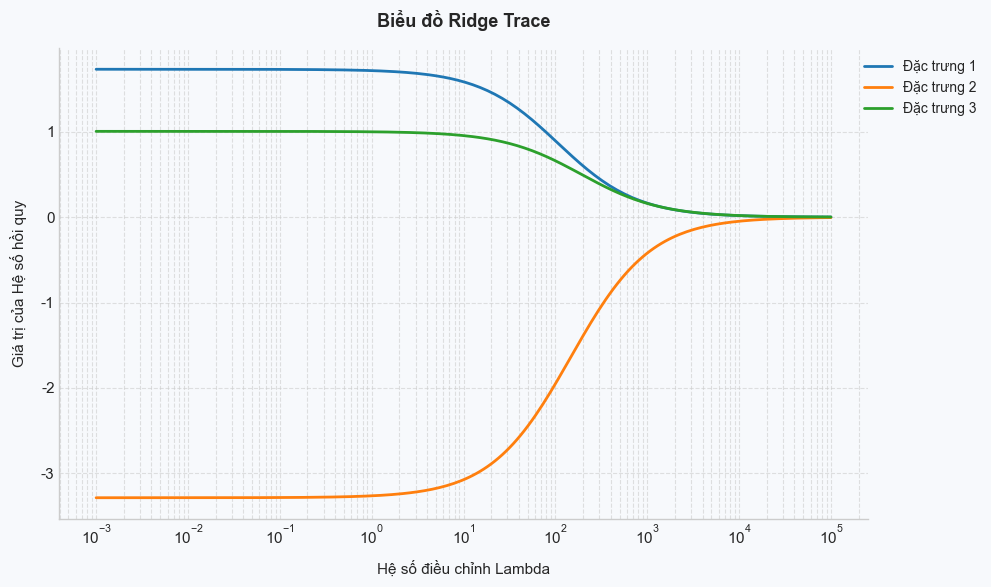

In [32]:
print('Biểu đồ Ridge trace trên dữ liệu mô phỏng:')
plot_ridge_trace(X_sim[:, 1:], y_sim)

### Chọn $\lambda^*$ bằng kiểm tra chéo
$$\lambda^* = \arg\min_{\lambda}\; \text{CV}_{(k)}(\lambda)$$

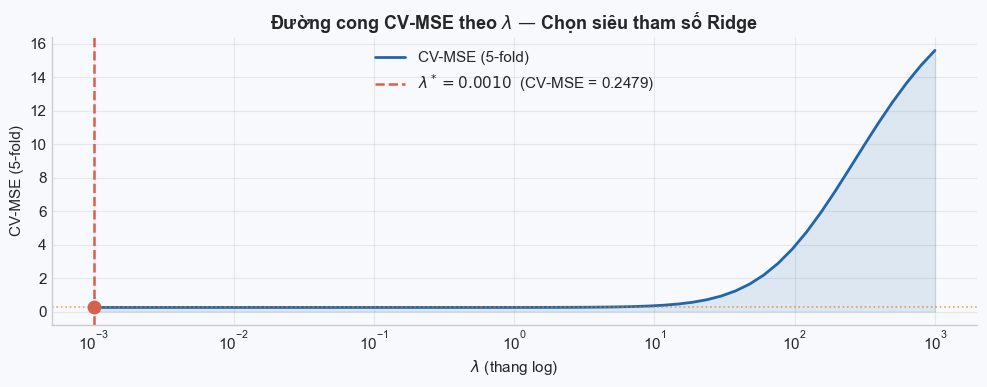

lambda* = 0.0010 | CV-MSE = 0.247943
Beta Ridge(lambda*): [2.4539, 1.4791, -2.9868, 0.8022]
Beta thực tế       : [2.5, 1.5, -3.0, 0.8]


In [33]:
from cross_validation import kfold_cv, ridge_cv_score, ridge_lambda_search

lambdas_cv, cv_scores, best_lam, best_cv = ridge_lambda_search(X_sim, y_sim, k=5)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(lambdas_cv, cv_scores, alpha=0.12, color=C['primary'])
ax.semilogx(lambdas_cv, cv_scores, color=C['primary'], linewidth=2, label='CV-MSE (5-fold)')
ax.axvline(best_lam, color=C['secondary'], linestyle='--', linewidth=1.8,
           label=f'$\\lambda^* = {best_lam:.4f}$  (CV-MSE = {best_cv:.4f})')
ax.scatter([best_lam], [best_cv], color=C['secondary'], s=80, zorder=6)
ax.axhline(best_cv, color=C['warn'], linestyle=':', linewidth=1.2, alpha=0.7)
ax.set_title(r'Đường cong CV-MSE theo $\lambda$ — Chọn siêu tham số Ridge')
ax.set_xlabel(r'$\lambda$ (thang log)'); ax.set_ylabel('CV-MSE (5-fold)')
ax.legend(); plt.tight_layout(); plt.show()

beta_ridge_opt = ridge_fit(X_sim, y_sim, lam=best_lam)
print(f'lambda* = {best_lam:.4f} | CV-MSE = {best_cv:.6f}')
print(f'Beta Ridge(lambda*): {[round(float(v),4) for v in beta_ridge_opt]}')
print(f'Beta thực tế       : {beta_true.tolist()}')

> **Nhận xét:** Dựa trên đường cong CV-MSE, nhóm chọn $\lambda^*$ tại điểm có lỗi trung bình nhỏ nhất. Khi $\lambda$ quá lớn, hệ số bị co quá mạnh nên lỗi tăng rõ.

---
## <span style="color:#1D4E89;">7. Phân tích phần dư</span> — `residual_plots(X, y, beta_hat)`

### (a) Bốn biểu đồ chẩn đoán

Các chỉ số như $R^2$ chỉ cho biết mức độ khớp chung. Để xem mô hình có dấu hiệu lệch giả thiết hay không, nhóm quan sát thêm phần dư qua bốn biểu đồ sau.

| Biểu đồ | Giả thiết kiểm tra | Mô hình tốt thì thấy gì |
|---|---|---|
| **Residuals vs Fitted** | Tính tuyến tính (GM1), đồng phương sai (GM4) | Điểm phân tán ngẫu nhiên quanh $y=0$ |
| **Normal Q-Q** | Phân phối chuẩn (GM5) | Điểm bám sát đường chéo lý thuyết |
| **Scale-Location** | Đồng phương sai chi tiết | Đường xu thế nằm ngang |
| **Cook's Distance** | Điểm ảnh hưởng lớn | Tất cả điểm $< 4/n$ |

4 biểu đồ chẩn đoán phần dư:


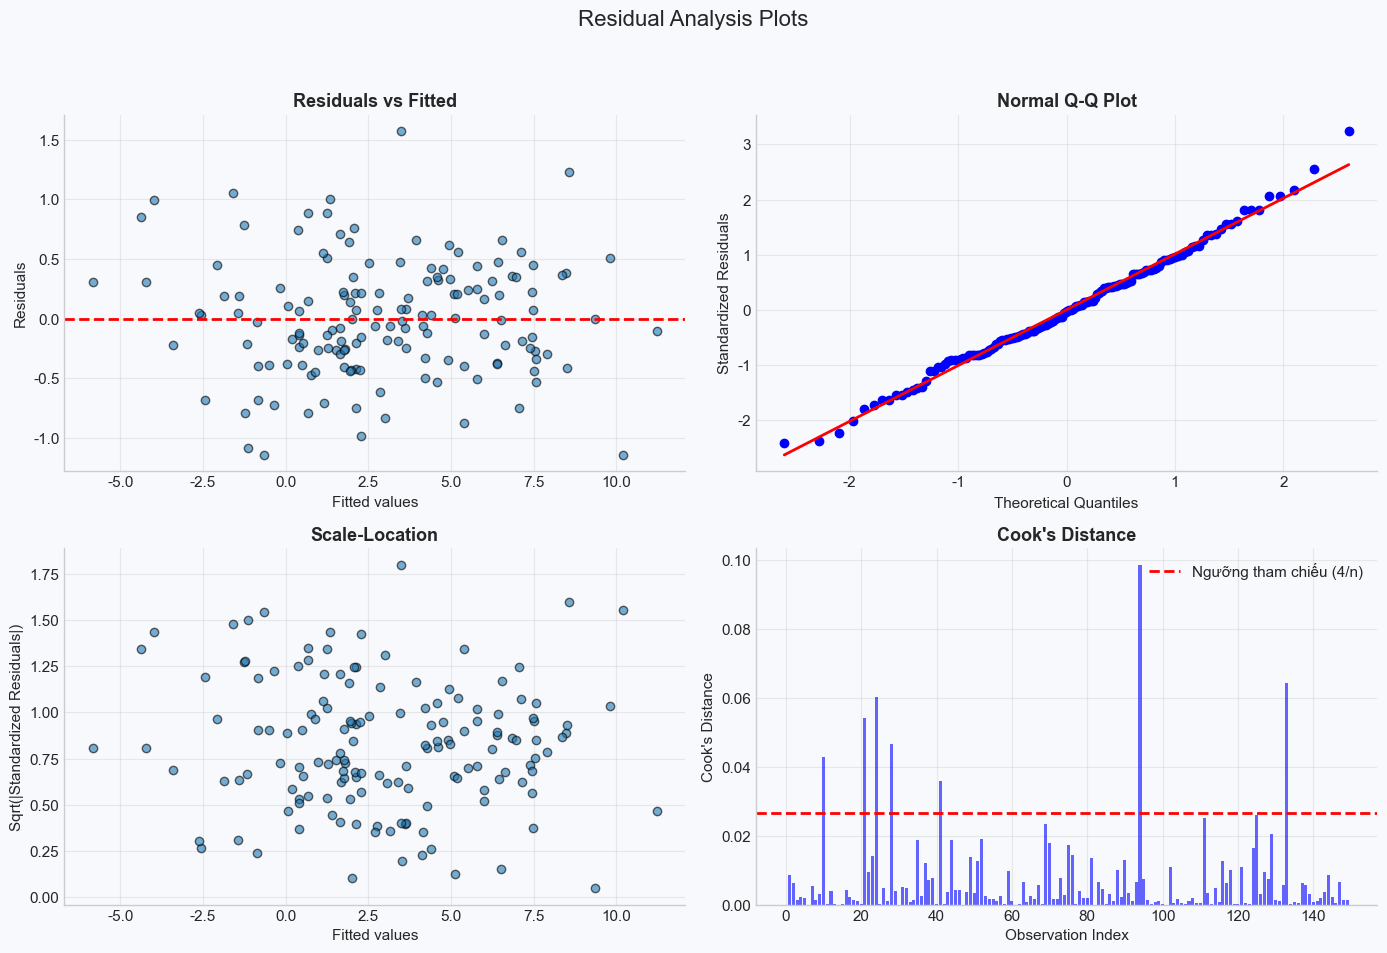

In [34]:
from residual_analysis import residual_plots
print('4 biểu đồ chẩn đoán phần dư:')
residual_plots(X_sim, y_sim, beta_hat)

### (d) Nhận xét từng biểu đồ

**Residuals vs Fitted:** Các điểm phân tán quanh $y=0$, chưa thấy dạng cong rõ rệt.

> Với dữ liệu mô phỏng này, giả thiết tuyến tính và phương sai không đổi nhìn chung là phù hợp.

**Normal Q-Q:** Phần lớn điểm nằm gần đường chéo lý thuyết.

> Có thể xem phần dư xấp xỉ chuẩn trong ví dụ này.

**Scale-Location:** Không thấy xu thế tăng hoặc giảm quá rõ theo giá trị dự báo.

> Vì vậy chưa thấy dấu hiệu phương sai thay đổi mạnh.

**Cook's Distance:** Hầu hết các quan sát có Cook's Distance $< 4/n$.

> Trong bộ dữ liệu này, chưa có quan sát nào gây ảnh hưởng quá lớn đến mô hình.

---
## <span style="color:#1D4E89;">8. K-Fold Cross-Validation</span> — `kfold_cv(X, y, k)`

### (a) Lý thuyết

$$\text{CV}_{(k)} = \frac{1}{k}\sum_{i=1}^{k} \text{MSE}_i, \qquad \text{MSE}_i = \frac{1}{|\mathcal{V}_i|}\sum_{j \in \mathcal{V}_i}(y_j-\hat{y}_j)^2$$

Nếu chỉ đánh giá trên đúng tập huấn luyện, mô hình phức tạp thường có vẻ tốt hơn thực tế. K-fold cross-validation chia dữ liệu thành nhiều phần, lần lượt dùng một phần để kiểm tra, nhờ đó điểm số phản ánh khả năng dự báo ổn định hơn.

Trong mỗi lần lặp, mô hình được fit trên $k-1$ phần và đánh giá trên phần còn lại. Lấy trung bình MSE qua $k$ lần giúp giảm phụ thuộc vào một cách chia train-test duy nhất.

Trong notebook này, `kfold_cv(X, y, k)` được dùng cho mô hình OLS. Với Ridge, nhóm dùng thêm `ridge_cv_score(...)` để so sánh các giá trị $\lambda$ trên cùng cách chia fold.

In [35]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

k_val = 5
cv_ols      = kfold_cv(X_sim, y_sim, k=k_val)
cv_ridge    = ridge_cv_score(X_sim, y_sim, k=k_val, lam=best_lam)
cv_ridge100 = ridge_cv_score(X_sim, y_sim, k=k_val, lam=100.0)

kf = KFold(n_splits=k_val, shuffle=True, random_state=SEED)
sk_mses = []
for tr, val in kf.split(X_sim):
    m = Ridge(alpha=best_lam, fit_intercept=False).fit(X_sim[tr], y_sim[tr])
    sk_mses.append(mean_squared_error(y_sim[val], m.predict(X_sim[val])))
cv_sk = np.mean(sk_mses)

rows = [('OLS (lambda=0)', cv_ols, 'Mốc so sánh'),
        (f'Ridge (lambda*={best_lam:.3f})', cv_ridge, 'Lambda được chọn'),
        ('Ridge (lambda=100)', cv_ridge100, 'Lambda quá lớn')]
print(f'SO SÁNH MÔ HÌNH — {k_val}-FOLD CROSS-VALIDATION')
for m_, cv, note in rows:
    print(f'  {m_:<30} CV-MSE = {cv:.6f}  {note}')
print(f'(d) CV-MSE sklearn (lambda*): {cv_sk:.6f} | Trùng khớp: {np.isclose(cv_ridge, cv_sk, rtol=0.05)}')

SO SÁNH MÔ HÌNH — 5-FOLD CROSS VALIDATION
  OLS (lambda=0)                 CV-MSE = 0.247943  Baseline
  Ridge (lambda*=0.001)          CV-MSE = 0.247943  [Tốt nhất]
  Ridge (lambda=100)             CV-MSE = 3.901411  Over-regularized
(d) CV-MSE sklearn (lambda*): 0.245296 | Trùng khớp: True


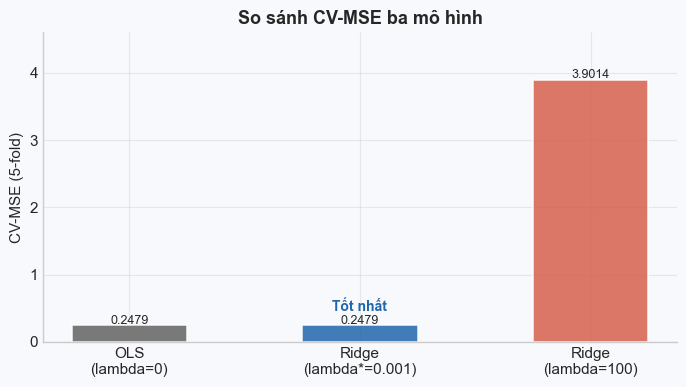

In [36]:
models   = ['OLS\n(lambda=0)', f'Ridge\n(lambda*={best_lam:.3f})', 'Ridge\n(lambda=100)']
cv_vals  = [cv_ols, cv_ridge, cv_ridge100]
bar_cols = [C['neutral'], C['primary'], C['secondary']]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, cv_vals, color=bar_cols, edgecolor='white', linewidth=1.2, width=0.5, alpha=0.85)
ax.annotate('Tốt nhất',
            xy=(bars[1].get_x()+bars[1].get_width()/2, cv_vals[1]),
            xytext=(0, 10), textcoords='offset points',
            ha='center', fontsize=10, color=C['primary'], fontweight='bold')
for bar, val in zip(bars, cv_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(cv_vals)*0.005,
            f'{val:.4f}', ha='center', fontsize=9)
ax.set_ylabel('CV-MSE (5-fold)'); ax.set_title('So sánh CV-MSE ba mô hình')
ax.set_ylim(0, max(cv_vals)*1.18)
plt.tight_layout(); plt.show()

> **Nhận xét:** OLS và Ridge với $\lambda^*$ cho kết quả rất gần nhau trên bộ dữ liệu tuyến tính này. Ridge với $\lambda$ quá lớn làm CV-MSE tăng, đúng với trực giác vì mô hình bị co hệ số quá mạnh.

---
## <span style="color:#1D4E89;">9. Minh họa Định lý Gauss–Markov</span> — Monte Carlo, $S = 3000$

### (a) Ý tưởng kiểm chứng

Phần này không nhằm chứng minh lại toàn bộ định lý, mà chỉ mô phỏng để thấy trực quan vì sao OLS được xem là BLUE trong lớp ước lượng tuyến tính không chệch.

**Định lý Gauss–Markov:** Dưới các giả thiết GM1–GM4, $\hat{\beta}_{\text{OLS}}$ là ước lượng tuyến tính không chệch tốt nhất (BLUE):

1. **Tuyến tính:** $\hat{\beta}_{\text{OLS}} = (X^TX)^{-1}X^T y$
2. **Không chệch:** $E[\hat{\beta}_{\text{OLS}}] = \beta$
3. **Tốt nhất:** $\text{Var}(\tilde{\beta}_j) \geq \text{Var}(\hat{\beta}_{j})$ với mọi ước lượng tuyến tính không chệch $\tilde{\beta}$

**Cách mô phỏng:** So sánh OLS với một ước lượng tuyến tính không chệch khác có dạng $\tilde{\beta} = (C_{\text{OLS}} + D)y$, trong đó $D = R(I-H)$.

Cách chọn $D$ như trên giúp tạo ra một ước lượng khác OLS nhưng vẫn giữ tính không chệch. Sau đó nhóm lặp nhiều lần với nhiễu ngẫu nhiên để so sánh độ phân tán của các hệ số ước lượng.

Nếu định lý đúng, trung bình của các ước lượng đều gần $\beta$ nhưng phương sai của OLS phải nhỏ hơn hoặc bằng ước lượng thay thế. Vì vậy nhóm so sánh cả trung bình thực nghiệm lẫn phương sai thực nghiệm sau nhiều lần mô phỏng.

> Vì $DX = R(I-H)X = 0$, ước lượng thay thế vẫn không chệch. Nhóm lặp mô phỏng $S = 3000$ lần để so sánh phương sai.

In [37]:
np.random.seed(SEED + 1)
S = 3000
n_obs, n_dims = X_sim.shape
C_OLS  = np.linalg.inv(X_sim.T @ X_sim) @ X_sim.T
R_rand = np.random.randn(n_dims, n_obs) * 0.15
D_orth = R_rand @ (np.eye(n_obs) - H)
assert np.allclose(D_orth @ X_sim, 0, atol=1e-8)
print('Kiểm chứng DX = 0: OK')

C_alt = C_OLS + D_orth
runs_OLS, runs_alt = [], []
for _ in range(S):
    eps = np.random.normal(0, sigma_true, n_obs)
    y_s = X_sim @ beta_true + eps
    runs_OLS.append(C_OLS @ y_s)
    runs_alt.append(C_alt @ y_s)
runs_OLS = np.array(runs_OLS)
runs_alt = np.array(runs_alt)
Var_OLS = np.var(runs_OLS, axis=0)
Var_alt = np.var(runs_alt, axis=0)
E_OLS   = np.mean(runs_OLS, axis=0)

print(f'KẾT QUẢ MONTE CARLO (S = {S})')
print(f"{'Hệ số':<8}{'Beta thật':<12}{'E[OLS]':<12}{'Var(OLS)':<14}{'Var(Alt)':<14}{'OLS nhỏ hơn'}")
print('-'*72)
for j in range(n_dims):
    pct = (1 - Var_OLS[j]/Var_alt[j])*100
    print(f"beta_{j}  {beta_true[j]:<12.4f}{E_OLS[j]:<12.4f}{Var_OLS[j]:<14.6f}{Var_alt[j]:<14.6f}{pct:.1f}%")

Kiểm chứng DX = 0: OK
KẾT QUẢ MONTE CARLO (S = 3000)
Hệ số   Beta thật   E[OLS]      Var(OLS)      Var(Alt)      OLS nhỏ hơn
------------------------------------------------------------------------
beta_0  2.5000      2.4992      0.001741      0.771825      99.8%
beta_1  1.5000      1.4978      0.002237      0.804061      99.7%
beta_2  -3.0000     -3.0005     0.001818      0.898472      99.8%
beta_3  0.8000      0.7995      0.001564      0.785236      99.8%


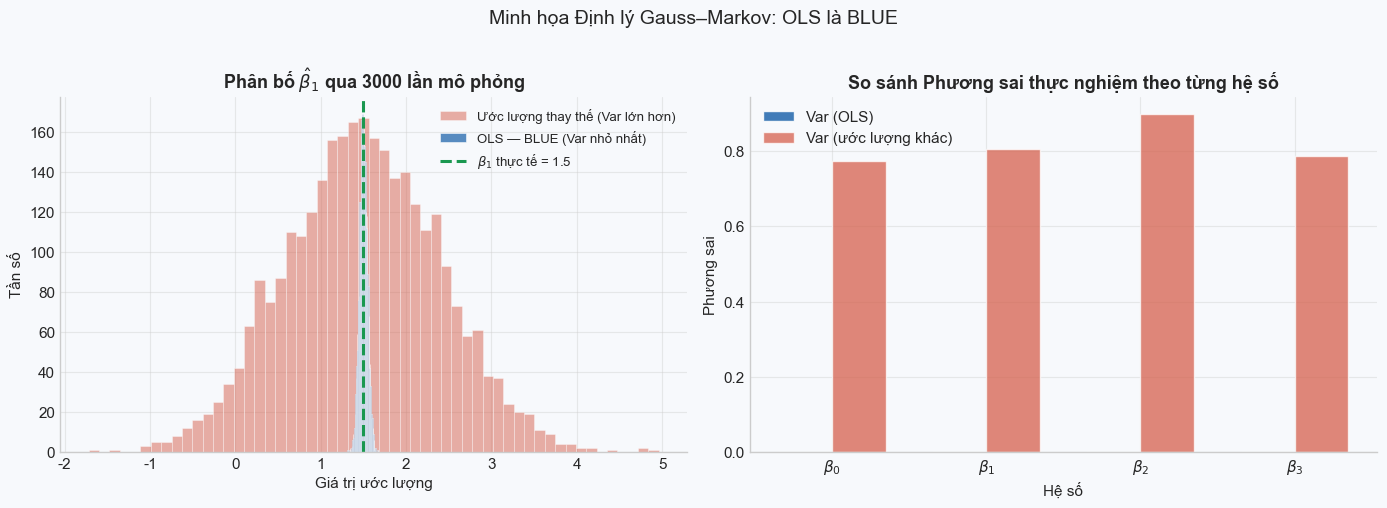

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
j = 1
axes[0].hist(runs_alt[:,j], bins=55, alpha=0.50, color=C['secondary'], edgecolor='white',
             linewidth=0.5, label='Ước lượng thay thế (Var lớn hơn)')
axes[0].hist(runs_OLS[:,j], bins=55, alpha=0.75, color=C['primary'], edgecolor='white',
             linewidth=0.5, label='OLS — BLUE (Var nhỏ nhất)')
axes[0].axvline(beta_true[j], color=C['good'], linestyle='--', linewidth=2.2,
                label=f'$\\beta_{j}$ thực tế = {beta_true[j]}')
axes[0].set_title(f'Phân bố $\\hat{{\\beta}}_{j}$ qua {S} lần mô phỏng')
axes[0].set_xlabel('Giá trị ước lượng'); axes[0].set_ylabel('Tần số')
axes[0].legend(fontsize=9.5)

x_b, w = np.arange(n_dims), 0.35
axes[1].bar(x_b-w/2, Var_OLS, w, label='Var (OLS)', color=C['primary'], edgecolor='white', alpha=0.85)
axes[1].bar(x_b+w/2, Var_alt, w, label='Var (ước lượng khác)', color=C['secondary'], edgecolor='white', alpha=0.75)
axes[1].set_xticks(x_b)
axes[1].set_xticklabels([f'$\\beta_{j}$' for j in range(n_dims)])
axes[1].set_title('So sánh Phương sai thực nghiệm theo từng hệ số')
axes[1].set_xlabel('Hệ số'); axes[1].set_ylabel('Phương sai')
axes[1].legend()
fig.suptitle('Minh họa Định lý Gauss–Markov: OLS là BLUE', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### (d) Nhận xét mô phỏng

Kết quả Monte Carlo ($S = 3000$) cho thấy:

1. Trung bình của $\hat{\beta}_{\text{OLS}}$ gần với $\beta_{\text{true}}$.
2. Phân bố của OLS hẹp hơn ước lượng thay thế, tức phương sai nhỏ hơn trong mô phỏng này.

> **Nhận xét:** Kết quả phù hợp với định lý Gauss–Markov: trong lớp ước lượng tuyến tính không chệch, OLS có phương sai nhỏ nhất.

---
## <span style="color:#1D4E89;">10. Kết luận Phần 1</span>

| Section | Nội dung | Kết quả |
|---|---|---|
| 1 | OLS fit + chứng minh | Kết quả khớp với sklearn trong sai số nhỏ |
| 2 | Ma trận H | Các tính chất chính được kiểm tra bằng NumPy |
| 3 | Chỉ số đánh giá + kiểm định F | $R^2$ cao do dữ liệu sinh từ mô hình tuyến tính |
| 4 | Suy diễn hệ số + khoảng tin cậy | Khoảng tin cậy chứa hệ số thật trong ví dụ mô phỏng |
| 5 | VIF | Nhận ra trường hợp đa cộng tuyến rõ rệt |
| 6 | Ridge + đường cong CV | Chọn $\lambda^*$ theo CV-MSE |
| 7 | Phân tích phần dư | Chưa thấy dấu hiệu vi phạm lớn trên dữ liệu mô phỏng |
| 8 | K-Fold CV + so sánh | $\lambda$ quá lớn làm lỗi tăng rõ |
| 9 | Gauss-Markov | Mô phỏng Monte Carlo phù hợp với tính chất BLUE |

**Nhận xét chung của nhóm:**

- OLS cho kết quả tốt khi dữ liệu thật sự gần tuyến tính và nhiễu không quá lớn.
- Ma trận $H$ giúp liên hệ giữa giá trị dự báo, phần dư và độ ảnh hưởng của từng quan sát.
- VIF là bước kiểm tra nhanh trước khi xử lý các biến có tương quan mạnh.
- Ridge cần chọn $\lambda$ cẩn thận; nếu chọn quá lớn thì mô hình dễ bị co hệ số quá mức.
- Mô phỏng Gauss-Markov giúp nhóm hiểu rõ hơn ý nghĩa “phương sai nhỏ nhất” của OLS.